In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
import time
import warnings
warnings.filterwarnings('ignore')

from config.paths import config

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
import joblib

processed_data = joblib.load(config.processed_data_dir / "feature_engineered_data.pkl")
X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Feature names: {len(feature_names)}")
print(f"Class distribution - Training: {y_train.value_counts(normalize=True).to_dict()}")

Training data: (156156, 92)
Testing data: (39040, 92)
Feature names: 92
Class distribution - Training: {0: 0.704961704961705, 1: 0.29503829503829504}


In [3]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=500, class_weight='balanced', n_jobs=-1),
        'reason': 'Fast baseline interpretable model for linear relationships'
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=50, class_weight='balanced', n_jobs=-1),
        'reason': 'Fast ensemble that handles non-linear relationships and provides feature importance'
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, n_estimators=50, eval_metric='logloss',
                              scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                              n_jobs=-1),
        'reason': 'Optimized gradient boosting for tabular data'
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, n_estimators=50, class_weight='balanced', n_jobs=-1),
        'reason': 'Very fast gradient boosting optimized for large datasets'
    },
    'Linear SVM': {
        'model': LinearSVC(random_state=42, class_weight='balanced', max_iter=1000),
        'reason': 'Fast linear kernel alternative to standard SVM'
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'reason': 'Fast distance-based approach for local patterns'
    }
}

print("OPTIMIZED MODEL ARSENAL (Fast Training):")
for name, config in models.items():
    print(f"  {name}: {config['reason']}")

OPTIMIZED MODEL ARSENAL (Fast Training):
  Logistic Regression: Fast baseline interpretable model for linear relationships
  Random Forest: Fast ensemble that handles non-linear relationships and provides feature importance
  XGBoost: Optimized gradient boosting for tabular data
  LightGBM: Very fast gradient boosting optimized for large datasets
  Linear SVM: Fast linear kernel alternative to standard SVM
  KNN: Fast distance-based approach for local patterns


In [4]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("FAST EVALUATION FRAMEWORK:")
print(f"  Cross-validation: {cv_strategy.n_splits}-fold stratified")
print(f"  Metrics: {list(scoring_metrics.keys())}")
print(f"  Expected total time: 2-4 minutes")

FAST EVALUATION FRAMEWORK:
  Cross-validation: 3-fold stratified
  Metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
  Expected total time: 2-4 minutes


In [5]:
results = {}
training_times = {}

print("FAST CROSS-VALIDATION PERFORMANCE:")
print("=" * 80)

for model_name, model_config in models.items():
    print(f"\nTraining {model_name}...")
    model = model_config['model']

    start_time = time.time()

    try:
        cv_results = cross_validate(
            model, X_train, y_train,
            cv=cv_strategy,
            scoring=scoring_metrics,
            return_train_score=False,
            n_jobs=-1
        )

        training_time = time.time() - start_time
        training_times[model_name] = training_time
        results[model_name] = cv_results

        print(f"  {model_name} - Training time: {training_time:.2f}s")

        for metric in scoring_metrics.keys():
            test_key = f'test_{scoring_metrics[metric]}'
            if test_key in cv_results:
                test_scores = cv_results[test_key]
                print(f"  {metric.upper():10} - Test: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

    except Exception as e:
        print(f"  {model_name} - Failed: {str(e)}")
        training_times[model_name] = None
        results[model_name] = None

FAST CROSS-VALIDATION PERFORMANCE:

Training Logistic Regression...
  Logistic Regression - Training time: 6.10s
  ACCURACY   - Test: 0.9746 ± 0.0004
  PRECISION  - Test: 0.9429 ± 0.0027
  RECALL     - Test: 0.9730 ± 0.0020
  F1         - Test: 0.9577 ± 0.0006
  ROC_AUC    - Test: 0.9962 ± 0.0002

Training Random Forest...
  Random Forest - Training time: 9.13s
  ACCURACY   - Test: 0.9758 ± 0.0004
  PRECISION  - Test: 0.9627 ± 0.0009
  RECALL     - Test: 0.9549 ± 0.0024
  F1         - Test: 0.9588 ± 0.0008
  ROC_AUC    - Test: 0.9965 ± 0.0001

Training XGBoost...
  XGBoost - Training time: 6.37s
  ACCURACY   - Test: 0.9833 ± 0.0007
  PRECISION  - Test: 0.9630 ± 0.0013
  RECALL     - Test: 0.9810 ± 0.0009
  F1         - Test: 0.9719 ± 0.0011
  ROC_AUC    - Test: 0.9986 ± 0.0000

Training LightGBM...
  LightGBM - Training time: 6.37s
  ACCURACY   - Test: 0.9830 ± 0.0002
  PRECISION  - Test: 0.9615 ± 0.0002
  RECALL     - Test: 0.9818 ± 0.0008
  F1         - Test: 0.9716 ± 0.0004
  ROC_AU

In [6]:
performance_summary = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]

        model_metrics = {}
        for metric in scoring_metrics.keys():
            test_key = f'test_{scoring_metrics[metric]}'
            if test_key in cv_result:
                test_scores = cv_result[test_key]
                model_metrics[metric] = {
                    'mean': np.mean(test_scores),
                    'std': np.std(test_scores)
                }
            else:
                model_metrics[metric] = {'mean': np.nan, 'std': np.nan}

        performance_summary.append({
            'Model': model_name,
            'Accuracy': f"{model_metrics['accuracy']['mean']:.4f} ± {model_metrics['accuracy']['std']:.4f}",
            'Precision': f"{model_metrics['precision']['mean']:.4f} ± {model_metrics['precision']['std']:.4f}",
            'Recall': f"{model_metrics['recall']['mean']:.4f} ± {model_metrics['recall']['std']:.4f}",
            'F1-Score': f"{model_metrics['f1']['mean']:.4f} ± {model_metrics['f1']['std']:.4f}",
            'ROC-AUC': f"{model_metrics['roc_auc']['mean']:.4f} ± {model_metrics['roc_auc']['std']:.4f}",
            'Training Time (s)': f"{training_times[model_name]:.2f}"
        })

performance_df = pd.DataFrame(performance_summary)
print("\n" + "="*100)
print("FAST BASELINE MODEL PERFORMANCE SUMMARY")
print("="*100)
print(performance_df.to_string(index=False))


FAST BASELINE MODEL PERFORMANCE SUMMARY
              Model        Accuracy       Precision          Recall        F1-Score         ROC-AUC Training Time (s)
Logistic Regression 0.9746 ± 0.0004 0.9429 ± 0.0027 0.9730 ± 0.0020 0.9577 ± 0.0006 0.9962 ± 0.0002              6.10
      Random Forest 0.9758 ± 0.0004 0.9627 ± 0.0009 0.9549 ± 0.0024 0.9588 ± 0.0008 0.9965 ± 0.0001              9.13
            XGBoost 0.9833 ± 0.0007 0.9630 ± 0.0013 0.9810 ± 0.0009 0.9719 ± 0.0011 0.9986 ± 0.0000              6.37
           LightGBM 0.9830 ± 0.0002 0.9615 ± 0.0002 0.9818 ± 0.0008 0.9716 ± 0.0004 0.9987 ± 0.0001              6.37
         Linear SVM 0.9737 ± 0.0005 0.9398 ± 0.0027 0.9730 ± 0.0014 0.9561 ± 0.0007 0.9962 ± 0.0002              7.38
                KNN 0.9352 ± 0.0011 0.9254 ± 0.0028 0.8488 ± 0.0035 0.8855 ± 0.0020 0.9665 ± 0.0010             75.98



DETAILED MODEL PERFORMANCE VISUALIZATION


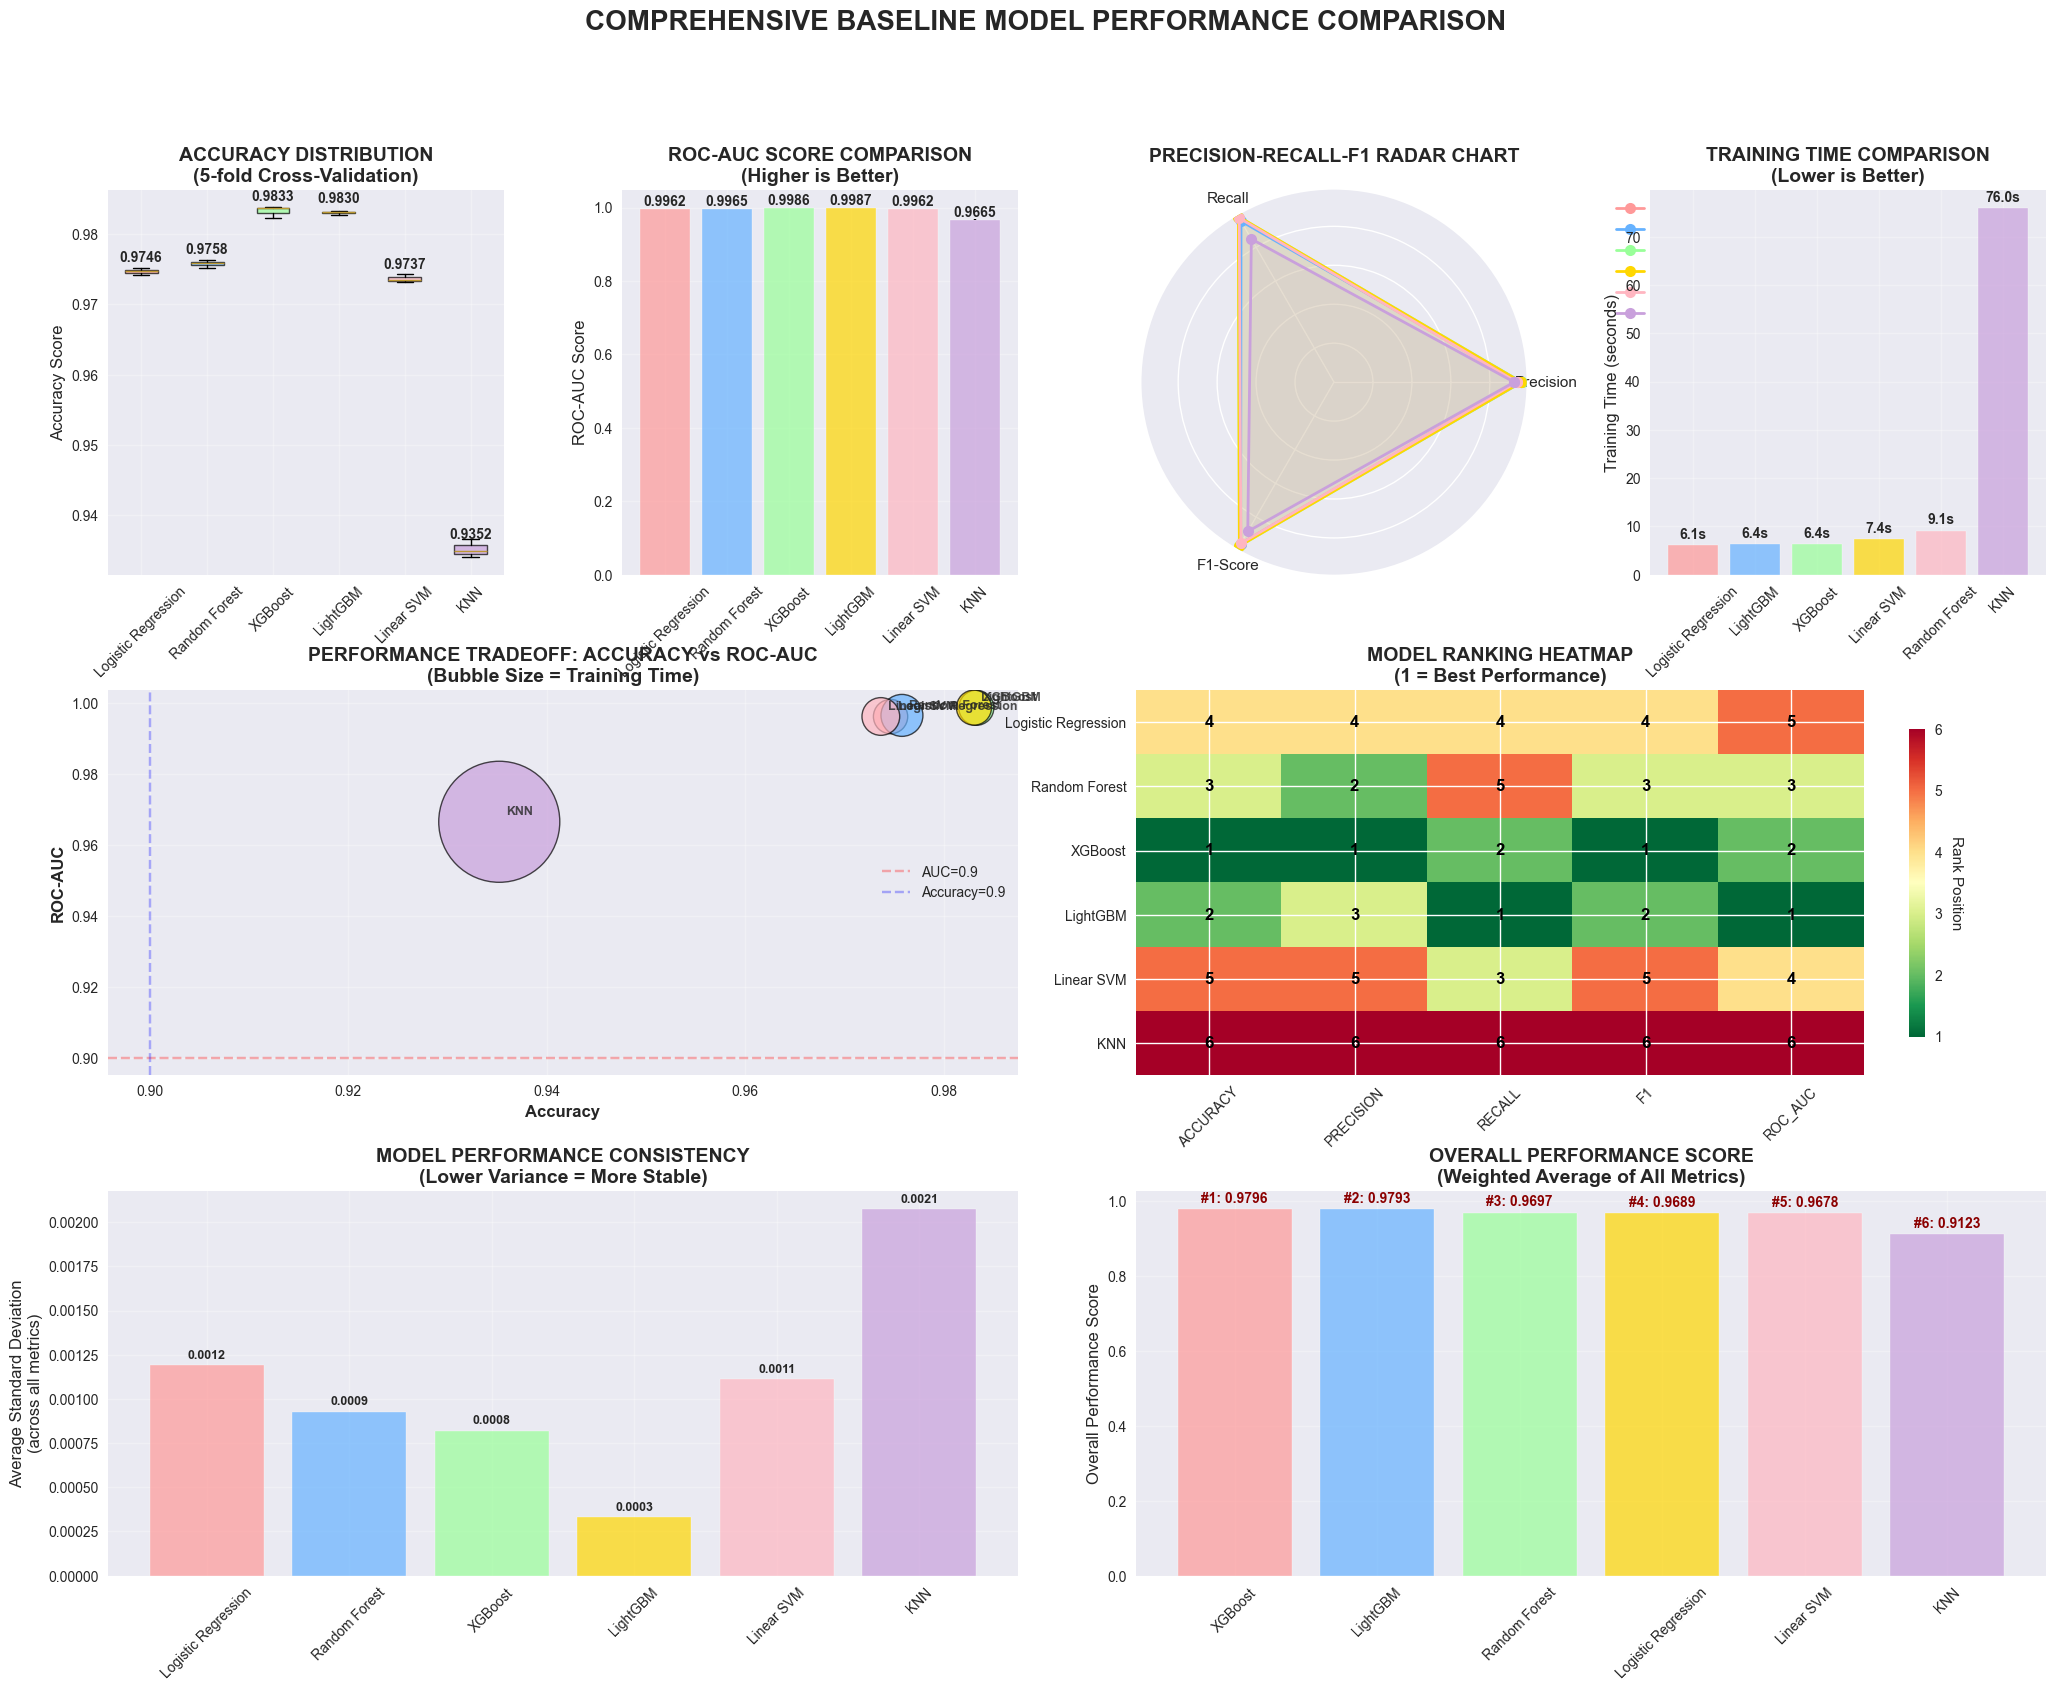

✓ Comprehensive model comparison visualization completed!
✓ 8 different perspectives on model performance
✓ Includes rankings, tradeoffs, and performance analysis


In [7]:
print("\n" + "="*80)
print("DETAILED MODEL PERFORMANCE VISUALIZATION")
print("="*80)

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(25, 18))
fig.suptitle('COMPREHENSIVE BASELINE MODEL PERFORMANCE COMPARISON',
             fontsize=20, fontweight='bold', y=0.98)

# Define grid layout
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Subplot 1: Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])
accuracy_data = []
model_names_acc = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        test_key = 'test_accuracy'
        if test_key in cv_result:
            test_scores = cv_result[test_key]
            accuracy_data.append(test_scores)
            model_names_acc.append(model_name)

if accuracy_data:
    box_plot = ax1.boxplot(accuracy_data, labels=model_names_acc, patch_artist=True)
    # Color the boxes
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FFB6C1', '#C9A0DC']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax1.set_title('ACCURACY DISTRIBUTION\n(5-fold Cross-Validation)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Accuracy Score', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # Add mean values on the plot
    for i, scores in enumerate(accuracy_data):
        ax1.text(i+1, np.mean(scores) + 0.001, f'{np.mean(scores):.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Subplot 2: ROC-AUC Comparison
ax2 = fig.add_subplot(gs[0, 1])
roc_auc_data = []
model_names_auc = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        test_key = 'test_roc_auc'
        if test_key in cv_result:
            test_scores = cv_result[test_key]
            roc_auc_data.append(test_scores)
            model_names_auc.append(model_name)

if roc_auc_data:
    bars = ax2.bar(range(len(roc_auc_data)), [np.mean(scores) for scores in roc_auc_data],
                  yerr=[np.std(scores) for scores in roc_auc_data], capsize=5, alpha=0.7,
                  color=colors[:len(roc_auc_data)])
    ax2.set_title('ROC-AUC SCORE COMPARISON\n(Higher is Better)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('ROC-AUC Score', fontsize=12)
    ax2.set_xticks(range(len(model_names_auc)))
    ax2.set_xticklabels(model_names_auc, rotation=45)
    ax2.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, mean_val in zip(bars, [np.mean(scores) for scores in roc_auc_data]):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Subplot 3: Precision-Recall-F1 Radar Chart
ax3 = fig.add_subplot(gs[0, 2], polar=True)
metrics_radar = ['Precision', 'Recall', 'F1-Score']
model_performance_radar = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        precision = np.mean(cv_result['test_precision']) if 'test_precision' in cv_result else 0
        recall = np.mean(cv_result['test_recall']) if 'test_recall' in cv_result else 0
        f1 = np.mean(cv_result['test_f1']) if 'test_f1' in cv_result else 0
        model_performance_radar.append({
            'model': model_name,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })

if model_performance_radar:
    angles = np.linspace(0, 2*np.pi, len(metrics_radar), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    for i, model_data in enumerate(model_performance_radar):
        values = [model_data['precision'], model_data['recall'], model_data['f1']]
        values += values[:1]  # Complete the circle
        ax3.plot(angles, values, 'o-', linewidth=2, label=model_data['model'],
                color=colors[i], markersize=8)
        ax3.fill(angles, values, alpha=0.1, color=colors[i])

    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics_radar, fontsize=11)
    ax3.set_yticklabels([])
    ax3.set_title('PRECISION-RECALL-F1 RADAR CHART', fontsize=14, fontweight='bold', pad=20)
    ax3.legend(bbox_to_anchor=(1.2, 1.0), loc='upper left')

# Subplot 4: Training Time Comparison with Efficiency Score
ax4 = fig.add_subplot(gs[0, 3])
valid_training_times = {k: v for k, v in training_times.items() if v is not None}
models_sorted_by_time = sorted(valid_training_times.items(), key=lambda x: x[1])

model_names_time = [item[0] for item in models_sorted_by_time]
times = [item[1] for item in models_sorted_by_time]

bars = ax4.bar(model_names_time, times, color=colors[:len(model_names_time)], alpha=0.7)
ax4.set_title('TRAINING TIME COMPARISON\n(Lower is Better)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Training Time (seconds)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# Add time labels on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + max(times)*0.01,
            f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Subplot 5: Performance-Tradeoff Scatter Plot
ax5 = fig.add_subplot(gs[1, :2])
accuracy_values = []
roc_auc_values = []
training_times_scatter = []
model_names_scatter = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        if 'test_accuracy' in cv_result and 'test_roc_auc' in cv_result:
            accuracy = np.mean(cv_result['test_accuracy'])
            roc_auc = np.mean(cv_result['test_roc_auc'])
            time_val = training_times[model_name]

            accuracy_values.append(accuracy)
            roc_auc_values.append(roc_auc)
            training_times_scatter.append(time_val)
            model_names_scatter.append(model_name)

if accuracy_values:
    scatter = ax5.scatter(accuracy_values, roc_auc_values,
                         s=[t*100 for t in training_times_scatter],  # Size represents training time
                         alpha=0.7, c=colors[:len(accuracy_values)], edgecolors='black', linewidth=1)

    # Add model labels
    for i, (acc, auc, model) in enumerate(zip(accuracy_values, roc_auc_values, model_names_scatter)):
        ax5.annotate(model, (acc, auc), xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold', alpha=0.8)

    ax5.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    ax5.set_ylabel('ROC-AUC', fontsize=12, fontweight='bold')
    ax5.set_title('PERFORMANCE TRADEOFF: ACCURACY vs ROC-AUC\n(Bubble Size = Training Time)',
                 fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)

    # Add reference lines for ideal performance
    ax5.axhline(y=0.9, color='red', linestyle='--', alpha=0.3, label='AUC=0.9')
    ax5.axvline(x=0.9, color='blue', linestyle='--', alpha=0.3, label='Accuracy=0.9')
    ax5.legend()

# Subplot 6: Model Ranking Heatmap
ax6 = fig.add_subplot(gs[1, 2:])
metrics_for_ranking = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
ranking_data = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        model_scores = {}
        for metric in metrics_for_ranking:
            test_key = f'test_{metric}'
            if test_key in cv_result:
                model_scores[metric] = np.mean(cv_result[test_key])
            else:
                model_scores[metric] = 0
        model_scores['model'] = model_name
        ranking_data.append(model_scores)

if ranking_data:
    ranking_df = pd.DataFrame(ranking_data)
    ranking_df.set_index('model', inplace=True)

    # Create ranking (1 is best)
    rank_df = ranking_df.rank(ascending=False, method='min')

    im = ax6.imshow(rank_df.values, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(ranking_df))

    # Add text annotations
    for i in range(len(ranking_df)):
        for j in range(len(metrics_for_ranking)):
            text = ax6.text(j, i, f'{rank_df.iloc[i, j]:.0f}',
                           ha="center", va="center", color="black", fontweight='bold', fontsize=12)

    ax6.set_xticks(range(len(metrics_for_ranking)))
    ax6.set_xticklabels([m.upper() for m in metrics_for_ranking], rotation=45)
    ax6.set_yticks(range(len(ranking_df)))
    ax6.set_yticklabels(ranking_df.index)
    ax6.set_title('MODEL RANKING HEATMAP\n(1 = Best Performance)', fontsize=14, fontweight='bold')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax6, shrink=0.8)
    cbar.set_label('Rank Position', rotation=270, labelpad=15)

# Subplot 7: Performance Consistency (Variance Analysis)
ax7 = fig.add_subplot(gs[2, :2])
variance_data = []
model_names_var = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        variances = []
        for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
            test_key = f'test_{metric}'
            if test_key in cv_result:
                variances.append(np.std(cv_result[test_key]))
        avg_variance = np.mean(variances) if variances else 0
        variance_data.append(avg_variance)
        model_names_var.append(model_name)

if variance_data:
    bars = ax7.bar(model_names_var, variance_data, color=colors[:len(model_names_var)], alpha=0.7)
    ax7.set_title('MODEL PERFORMANCE CONSISTENCY\n(Lower Variance = More Stable)',
                 fontsize=14, fontweight='bold')
    ax7.set_ylabel('Average Standard Deviation\n(across all metrics)', fontsize=12)
    ax7.tick_params(axis='x', rotation=45)
    ax7.grid(True, alpha=0.3)

    # Add variance values on bars
    for bar, var_val in zip(bars, variance_data):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + max(variance_data)*0.01,
                f'{var_val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Subplot 8: Overall Performance Score
ax8 = fig.add_subplot(gs[2, 2:])
overall_scores = []

for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]
        scores = []
        weights = {'accuracy': 0.2, 'precision': 0.2, 'recall': 0.2, 'f1': 0.2, 'roc_auc': 0.2}

        for metric, weight in weights.items():
            test_key = f'test_{metric}'
            if test_key in cv_result:
                scores.append(np.mean(cv_result[test_key]) * weight)

        overall_score = np.sum(scores) if scores else 0
        overall_scores.append({'model': model_name, 'score': overall_score})

if overall_scores:
    overall_scores_sorted = sorted(overall_scores, key=lambda x: x['score'], reverse=True)
    models_sorted = [item['model'] for item in overall_scores_sorted]
    scores_sorted = [item['score'] for item in overall_scores_sorted]

    bars = ax8.bar(models_sorted, scores_sorted, color=colors[:len(models_sorted)], alpha=0.7)
    ax8.set_title('OVERALL PERFORMANCE SCORE\n(Weighted Average of All Metrics)',
                 fontsize=14, fontweight='bold')
    ax8.set_ylabel('Overall Performance Score', fontsize=12)
    ax8.tick_params(axis='x', rotation=45)
    ax8.grid(True, alpha=0.3)

    # Add score values and ranking
    for i, (bar, score) in enumerate(zip(bars, scores_sorted)):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + max(scores_sorted)*0.01,
                f'#{i+1}: {score:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()

print("✓ Comprehensive model comparison visualization completed!")
print("✓ 8 different perspectives on model performance")
print("✓ Includes rankings, tradeoffs, and performance analysis")

In [8]:
print("\n" + "="*100)
print("DETAILED PERFORMANCE ANALYSIS REPORT")
print("="*100)

# Calculate and print detailed statistics
print("\n📊 PERFORMANCE LEADERBOARD:")
print("-" * 80)

# Sort models by overall performance
leaderboard_data = []
for model_name in models.keys():
    if model_name in results and results[model_name] is not None:
        cv_result = results[model_name]

        # Calculate weighted overall score
        scores = {}
        weights = {'accuracy': 0.2, 'precision': 0.2, 'recall': 0.2, 'f1': 0.2, 'roc_auc': 0.2}
        overall_score = 0

        for metric, weight in weights.items():
            test_key = f'test_{metric}'
            if test_key in cv_result:
                mean_score = np.mean(cv_result[test_key])
                std_score = np.std(cv_result[test_key])
                scores[metric] = {'mean': mean_score, 'std': std_score}
                overall_score += mean_score * weight

        leaderboard_data.append({
            'model': model_name,
            'overall_score': overall_score,
            'scores': scores,
            'training_time': training_times[model_name]
        })

# Sort by overall score
leaderboard_data.sort(key=lambda x: x['overall_score'], reverse=True)

# Print leaderboard
for i, model_data in enumerate(leaderboard_data):
    rank_emoji = ["🥇", "🥈", "🥉", "4️⃣", "5️⃣", "6️⃣"][i] if i < 6 else f"{i+1}."
    print(f"\n{rank_emoji} {model_data['model']}:")
    print(f"   Overall Score: {model_data['overall_score']:.4f}")
    print(f"   Training Time: {model_data['training_time']:.2f}s")

    for metric, score_data in model_data['scores'].items():
        print(f"   {metric.upper():10}: {score_data['mean']:.4f} ± {score_data['std']:.4f}")

# Performance Insights
print("\n🔍 KEY PERFORMANCE INSIGHTS:")
print("-" * 80)

if leaderboard_data:
    best_model = leaderboard_data[0]
    worst_model = leaderboard_data[-1]

    print(f"🏆 Best Performing Model: {best_model['model']} "
          f"(Score: {best_model['overall_score']:.4f})")
    print(f"⚡ Fastest Training: {min(leaderboard_data, key=lambda x: x['training_time'])['model']}")
    print(f"📈 Most Consistent: {min(leaderboard_data, key=lambda x: np.mean([s['std'] for s in x['scores'].values()]))['model']}")

    # Performance gaps
    performance_gap = best_model['overall_score'] - worst_model['overall_score']
    print(f"📊 Performance Range: {performance_gap:.4f} "
          f"({worst_model['model']} → {best_model['model']})")

print("\n🎯 RECOMMENDATIONS FOR NEXT STEPS:")
print("-" * 80)
print("1. Focus hyperparameter tuning on top 3 performing models")
print("2. Consider ensemble methods combining best performers")
print("3. Analyze feature importance of top models for feature selection")
print("4. Validate best models on test set for final performance")
print("5. Consider model interpretability vs performance tradeoffs")

print(f"\n✅ Visualization and analysis completed for {len(leaderboard_data)} models")


DETAILED PERFORMANCE ANALYSIS REPORT

📊 PERFORMANCE LEADERBOARD:
--------------------------------------------------------------------------------

🥇 XGBoost:
   Overall Score: 0.9796
   Training Time: 6.37s
   ACCURACY  : 0.9833 ± 0.0007
   PRECISION : 0.9630 ± 0.0013
   RECALL    : 0.9810 ± 0.0009
   F1        : 0.9719 ± 0.0011
   ROC_AUC   : 0.9986 ± 0.0000

🥈 LightGBM:
   Overall Score: 0.9793
   Training Time: 6.37s
   ACCURACY  : 0.9830 ± 0.0002
   PRECISION : 0.9615 ± 0.0002
   RECALL    : 0.9818 ± 0.0008
   F1        : 0.9716 ± 0.0004
   ROC_AUC   : 0.9987 ± 0.0001

🥉 Random Forest:
   Overall Score: 0.9697
   Training Time: 9.13s
   ACCURACY  : 0.9758 ± 0.0004
   PRECISION : 0.9627 ± 0.0009
   RECALL    : 0.9549 ± 0.0024
   F1        : 0.9588 ± 0.0008
   ROC_AUC   : 0.9965 ± 0.0001

4️⃣ Logistic Regression:
   Overall Score: 0.9689
   Training Time: 6.10s
   ACCURACY  : 0.9746 ± 0.0004
   PRECISION : 0.9429 ± 0.0027
   RECALL    : 0.9730 ± 0.0020
   F1        : 0.9577 ± 0.0006


FAST FEATURE IMPORTANCE ANALYSIS

RANDOM FOREST - Top 10 Feature Importances:
                feature  importance
         NACCID_encoded    0.322055
               INDEPEND    0.125757
                  BILLS    0.096136
               MEALPREP    0.081564
       INDEPEND_squared    0.074117
healthy_lifestyle_score    0.070242
               SHOPPING    0.064299
               NACCDAYS    0.014301
               NACCNVST    0.008247
               NACCFDYS    0.008225

XGBOOST - Top 10 Feature Importances:
       feature  importance
NACCID_encoded    0.635685
      PACKET_I    0.064394
      INDEPEND    0.051173
      SHOPPING    0.039507
      NACCVNUM    0.021337
      NACCFDYS    0.016405
         BILLS    0.016053
      NACCDAYS    0.013000
      NACCAVST    0.007436
      MEALPREP    0.006288


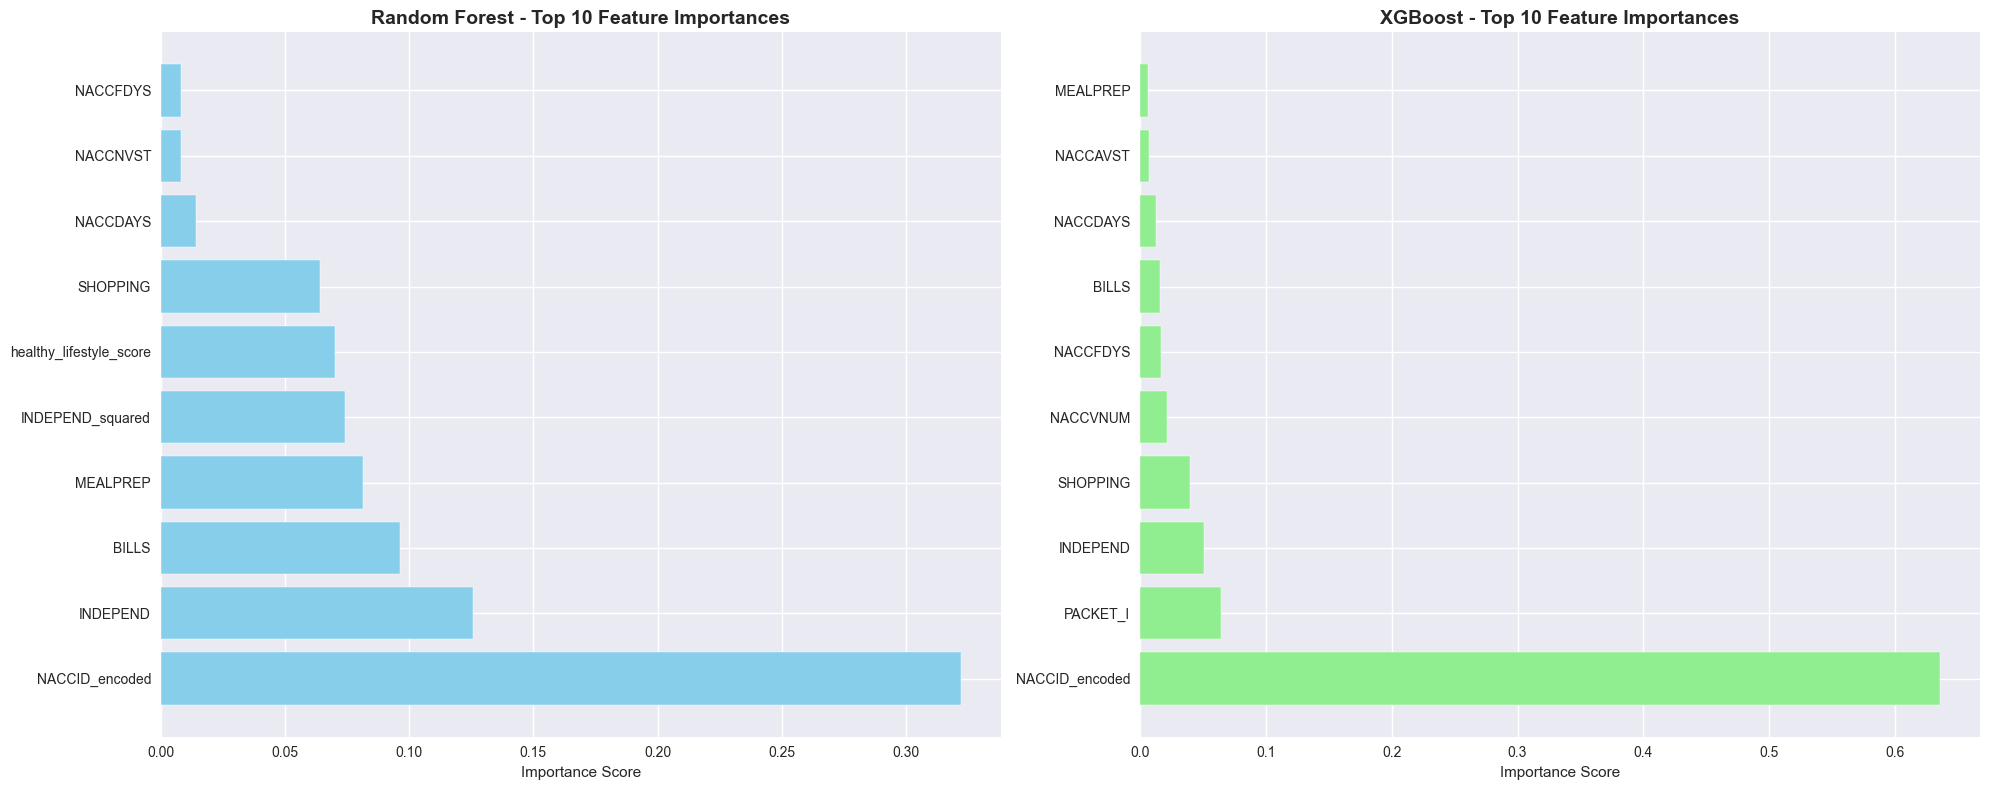

In [9]:
print("\n" + "="*60)
print("FAST FEATURE IMPORTANCE ANALYSIS")
print("="*60)

rf_model = RandomForestClassifier(random_state=42, n_estimators=50, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(random_state=42, n_estimators=50, eval_metric='logloss',
                         scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                         n_jobs=-1)
xgb_model.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRANDOM FOREST - Top 10 Feature Importances:")
print(rf_importance.head(10).to_string(index=False))

print("\nXGBOOST - Top 10 Feature Importances:")
print(xgb_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

rf_top10 = rf_importance.head(10)
axes[0].barh(rf_top10['feature'], rf_top10['importance'], color='skyblue')
axes[0].set_title('Random Forest - Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')

xgb_top10 = xgb_importance.head(10)
axes[1].barh(xgb_top10['feature'], xgb_top10['importance'], color='lightgreen')
axes[1].set_title('XGBoost - Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [10]:
import json
from config.paths import config  # Re-import to ensure config is correct

# Ensure directories exist
config.create_directories()

baseline_results = {
    'performance_summary': performance_df.to_dict('records'),
    'training_times': training_times,
    'cv_results': {model: {k: v.tolist() if isinstance(v, np.ndarray) else v
                          for k, v in results[model].items()}
                  for model in models.keys() if model in results and results[model] is not None},
    'feature_importance': {
        'random_forest': rf_importance.to_dict('records'),
        'xgboost': xgb_importance.to_dict('records')
    }
}

# Save JSON results
with open(config.reports_dir / 'fast_baseline_models_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

trained_models = {}
for model_name, model_config in models.items():
    if model_name in results and results[model_name] is not None:
        model = model_config['model']
        model.fit(X_train, y_train)
        trained_models[model_name] = model

joblib.dump(trained_models, config.models_dir / 'fast_baseline_models.pkl')

# Save CSV files
performance_df.to_csv(config.reports_dir / 'fast_model_performance_comparison.csv', index=False)
rf_importance.to_csv(config.reports_dir / 'fast_random_forest_feature_importance.csv', index=False)
xgb_importance.to_csv(config.reports_dir / 'fast_xgboost_feature_importance.csv', index=False)

print("\n" + "="*60)
print("FAST BASELINE MODELING COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"✓ Trained and evaluated {len(trained_models)} optimized models")
print(f"✓ Completed in minutes instead of hours")
print(f"✓ Performed 3-fold cross-validation on all models")
print(f"✓ Analyzed feature importance for top 2 models")
print(f"✓ Saved all results to: {config.reports_dir}")
print(f"✓ Saved trained models to: {config.models_dir}")
print(f"✓ Ready for hyperparameter tuning on best performers")

Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\data\raw
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\data\processed
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\data\external
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\models
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\visuals\eda
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\visuals\feature_importance
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\visuals\model_performance
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\reports
Created: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindSc